In [134]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [135]:
d = pd.read_csv('animals_hometask.csv')
d

,Animal,Type,Legs,Can_Fly,Color,Weight,Size
0,Frog,Bird,6.0,Yes,Yellow,3988.3,NaN
1,Rabbit,Amphibian,0.0,NaN,Black,1837.5,Medium
2,Tiger,Bird,8.0,NaN,Green,3644.1,NaN
3,Eagle,Mammal,8.0,Yes,Orange,2854.8,Small
4,Snake,Amphibian,8.0,NaN,Brown,4071.8,NaN
...,...,...,...,...,...,...,...
100,Rabbit,Reptile,6.0,No,Green,1171.8,NaN
101,Frog,Reptile,4.0,Yes,Yellow,3579.6,Large
102,Penguin,Mammal,6.0,NaN,Gray,215.7,Large
103,Cat,Bird,2.0,Yes,NaN,4394.2,Large


In [136]:
print(d.info())
print(d.isna().sum())
print(d.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Animal   93 non-null     str    
 1   Type     94 non-null     str    
 2   Legs     83 non-null     float64
 3   Can_Fly  64 non-null     str    
 4   Color    90 non-null     str    
 5   Weight   97 non-null     float64
 6   Size     69 non-null     str    
dtypes: float64(2), str(5)
memory usage: 5.9 KB
None
Animal     12
Type       11
Legs       22
Can_Fly    41
Color      15
Weight      8
Size       36
dtype: int64
5


In [137]:
d.dropna(inplace=True)
d.drop_duplicates(inplace=True)
print(d.info())
print(d.isna().sum())
print(d.duplicated().sum())

<class 'pandas.DataFrame'>
Index: 18 entries, 3 to 98
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Animal   18 non-null     str    
 1   Type     18 non-null     str    
 2   Legs     18 non-null     float64
 3   Can_Fly  18 non-null     str    
 4   Color    18 non-null     str    
 5   Weight   18 non-null     float64
 6   Size     18 non-null     str    
dtypes: float64(2), str(5)
memory usage: 1.1 KB
None
Animal     0
Type       0
Legs       0
Can_Fly    0
Color      0
Weight     0
Size       0
dtype: int64
0


In [138]:
d.head(2)

,Animal,Type,Legs,Can_Fly,Color,Weight,Size
3,Eagle,Mammal,8.0,Yes,Orange,2854.8,Small
7,Penguin,Reptile,2.0,No,Gray,4075.6,Medium


In [139]:
x = d.drop('Animal', axis=1)
y = d['Animal']
print(x.columns)

Index(['Type', 'Legs', 'Can_Fly', 'Color', 'Weight', 'Size'], dtype='str')


In [140]:
sc = StandardScaler()
le = LabelEncoder()
lb = LabelBinarizer()
x_num = x.select_dtypes(include='number')
x_num = sc.fit_transform(x_num)
yesno = d['Can_Fly']
yesno = lb.fit_transform(yesno)
x['Can_Fly'] = yesno
x['Color'] = le.fit_transform(x['Color'])
x['Type'] = le.fit_transform(x['Type'])
x['Size'] = le.fit_transform(x['Size'])
y = le.fit_transform(y)
x

,Type,Legs,Can_Fly,Color,Weight,Size
3,3,8.0,1,3,2854.8,2
7,4,2.0,0,2,4075.6,1
11,4,8.0,1,4,3351.7,2
12,2,2.0,1,5,1357.0,1
24,2,8.0,0,1,2566.8,1
26,0,6.0,0,5,4289.0,1
30,1,6.0,1,1,3055.7,0
35,4,8.0,0,1,4674.8,2
39,1,4.0,1,0,1835.7,0
41,2,8.0,1,2,3977.2,2


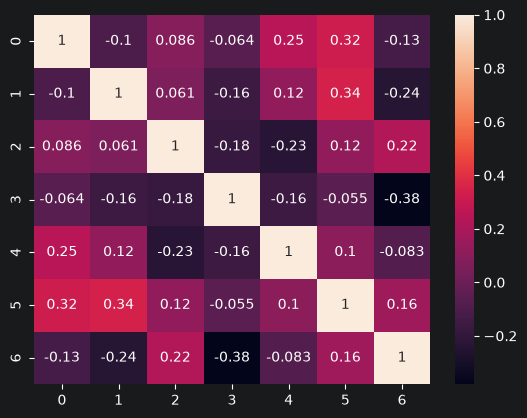

In [141]:
dn = np.column_stack((x,y))
dn = pd.DataFrame(dn)
sns.heatmap(dn.corr(), annot=True)
plt.show()

In [142]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [143]:
kn = KNeighborsClassifier()
kn.fit(x_train, y_train)
pred = kn.predict(x_test)

In [144]:
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       2.0
           7       0.00      0.00      0.00       1.0
          10       0.00      0.00      0.00       1.0

    accuracy                           0.00       4.0
   macro avg       0.00      0.00      0.00       4.0
weighted avg       0.00      0.00      0.00       4.0



/home/suupatruupa/Documents/hmph/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suupatruupa/Documents/hmph/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suupatruupa/Documents/hmph/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr